# Generate session regressors

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from visiomode_analysis import session
from visiomode_analysis.session import regressor

In [2]:
gng_path = "./test_data/example-gonogo-leverpush.json"

meta = session.get_metadata(gng_path)
df = session.get_trials(gng_path)

In [3]:
df

,animal_id,session_date,protocol,environment,experiment,start_time,stop_time,cue_onset,response,response_time,...,correction,pos_x,pos_y,dist_x,dist_y,sdt_type,stim_id,stim_period,stim_contrast,stim_freq
0,MM229,2022-03-09,gonogo,unknown,109hrb21d,4.484679,13.484679,9.484679,NaN,NaN,...,False,NaN,NaN,NaN,NaN,correct_rejection,isoluminantgray,NaN,NaN,NaN
1,MM229,2022-03-09,gonogo,unknown,109hrb21d,14.991839,19.065675,NaN,unknown,4.072411,...,False,400.0,240.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN
2,MM229,2022-03-09,gonogo,unknown,109hrb21d,19.067179,25.196554,24.067179,unknown,1.128456,...,False,400.0,240.0,0.0,0.0,hit,movinggrating,30,1.0,1.0
3,MM229,2022-03-09,gonogo,unknown,109hrb21d,26.700473,35.700473,31.700473,NaN,NaN,...,False,NaN,NaN,NaN,NaN,correct_rejection,isoluminantgray,NaN,NaN,NaN
4,MM229,2022-03-09,gonogo,unknown,109hrb21d,37.206945,43.881072,42.206945,unknown,1.670673,...,False,400.0,240.0,0.0,0.0,hit,movinggrating,30,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
300,MM229,2022-03-09,gonogo,unknown,109hrb21d,1765.847014,1774.055825,1770.847014,unknown,3.207015,...,True,400.0,240.0,0.0,0.0,false_alarm,isoluminantgray,NaN,NaN,NaN
301,MM229,2022-03-09,gonogo,unknown,109hrb21d,1774.057461,1781.851167,1779.057461,unknown,2.791260,...,True,400.0,240.0,0.0,0.0,false_alarm,isoluminantgray,NaN,NaN,NaN
302,MM229,2022-03-09,gonogo,unknown,109hrb21d,1781.852839,1786.325765,NaN,unknown,4.472022,...,True,400.0,240.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN
303,MM229,2022-03-09,gonogo,unknown,109hrb21d,1786.327744,1795.327744,1791.327744,NaN,NaN,...,True,NaN,NaN,NaN,NaN,correct_rejection,isoluminantgray,NaN,NaN,NaN


In [4]:
meta

{'animal_id': 'MM229',
 'experiment': '109hrb21d',
 'session_date': datetime.date(2022, 3, 9),
 'environment': 'unknown',
 'protocol': 'gonogo',
 'version': 'unknown',
 'duration': 30.0,
 'session_start_time': '2022-03-09T12:04:03.108928',
 'response_device': 'leverpush',
 'reward_profile': 'waterreward',
 'stimulus_duration': 4000.0,
 'iti': 5000.0,
 'corrections_enabled': 'true',
 'device': 'meso-2',
 'stimuli': {'target_id': 'movinggrating',
  'target_period': '30',
  'target_contrast': '1.0',
  'target_freq': '1.0',
  'distractor_id': 'isoluminantgray'},
 'notes': ''}

In [5]:
# Generate regressors for the session
# Uniformly sampled timestamps (would otherwise be external, e.g. imaging session)

timestamps = np.arange(0, df.stop_time.max(), 0.04)  # Mock imaging at 25 Hz (processed)

In [6]:
GO_STIM = "movinggrating"
NOGO_STIM = "isoluminantgray"

In [7]:
regr_stim_go = []
regr_stim_nogo = []
regr_resp_cuedpush = []
regr_resp_uncuedpush = []
regr_resp_hold = []
regr_reward = []

leverpush_rt = np.nanmedian(df[df.response.notna()].response_time.values)

trial_idx = []

for idx, timestamp in enumerate(timestamps):
    trial = df[(df["start_time"] < timestamp) & (df["stop_time"] > timestamp)]
    if trial.empty:
        continue

    trial_idx.append(idx)

    # Stimulus regressors
    regr_stim_go.append(
        1
        if (
            (trial.stim_id.values[0] == GO_STIM)
            & (timestamp >= trial.cue_onset.values[0])
            & (timestamp <= trial.cue_onset.values[0] + 150)
        )
        else 0
    )
    regr_stim_nogo.append(
        1
        if (
            (trial.stim_id.values[0] == NOGO_STIM)
            & (timestamp >= trial.cue_onset.values[0])
            & (timestamp <= trial.cue_onset.values[0] + 150)
        )
        else 0
    )

    # Response regressors
    regr_resp_cuedpush.append(
        1
        if (
            (trial.response.notna().values[0])
            & (trial.outcome.values[0] != "precued")
            & (timestamp >= trial.cue_onset.values[0] + leverpush_rt - 0.07)
            & (timestamp <= trial.cue_onset.values[0] + leverpush_rt)
        )
        else 0
    )  # 70 ms is lever push duration from Dacre et al. 2021
    regr_resp_uncuedpush.append(
        1
        if (
            (trial.outcome.values[0] == "precued")
            & (timestamp >= trial.stop_time.values[0] - 0.07)  # 70 ms is lever push duration from Dacre et al. 2021
            & (timestamp <= trial.stop_time.values[0])
        )
        else 0
    )
    regr_resp_hold.append(
        1
        if (
            (trial.response.isna().values[0])
            & (timestamp >= trial.cue_onset.values[0] + leverpush_rt - 0.07)
            & (timestamp <= trial.cue_onset.values[0] + leverpush_rt)
        )
        else 0
    )

    # Reward regressors
    if trial.index > 0:
        previous_trial = df.iloc[df.index.get_loc(trial.index[0]) - 1]  # type: ignore
        regr_reward.append(
            1 if ((previous_trial.outcome == "correct") & (timestamp <= trial.start_time.values[0] + 1.5)) else 0
        )

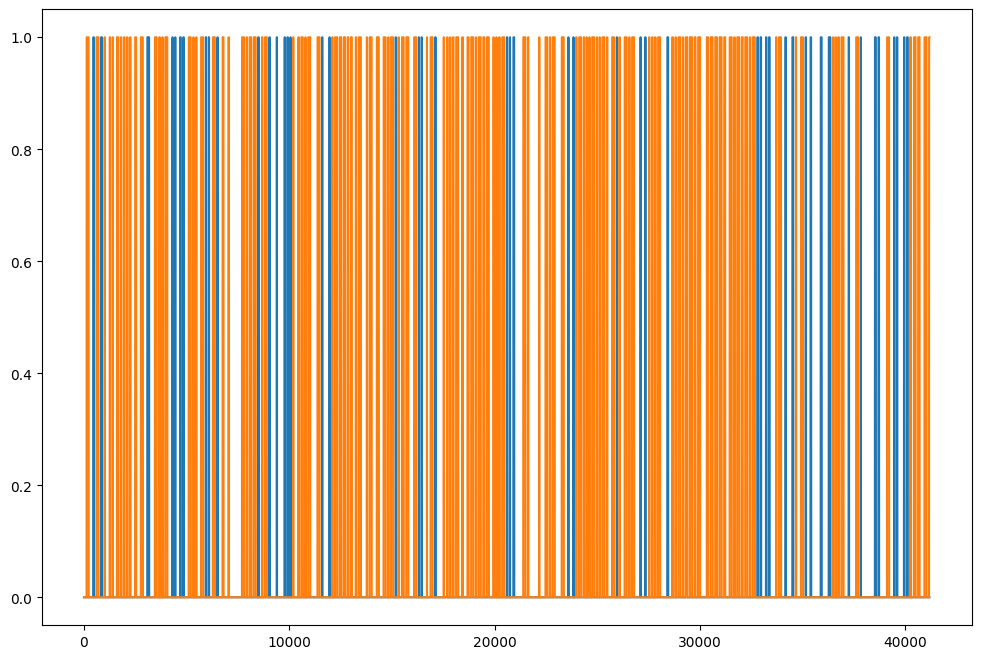

In [8]:
# Plot stimulus regressors
plt.figure(figsize=(12, 8))
plt.plot(regr_stim_go, label="Stimulus Go")
plt.plot(regr_stim_nogo, label="Stimulus NoGo")


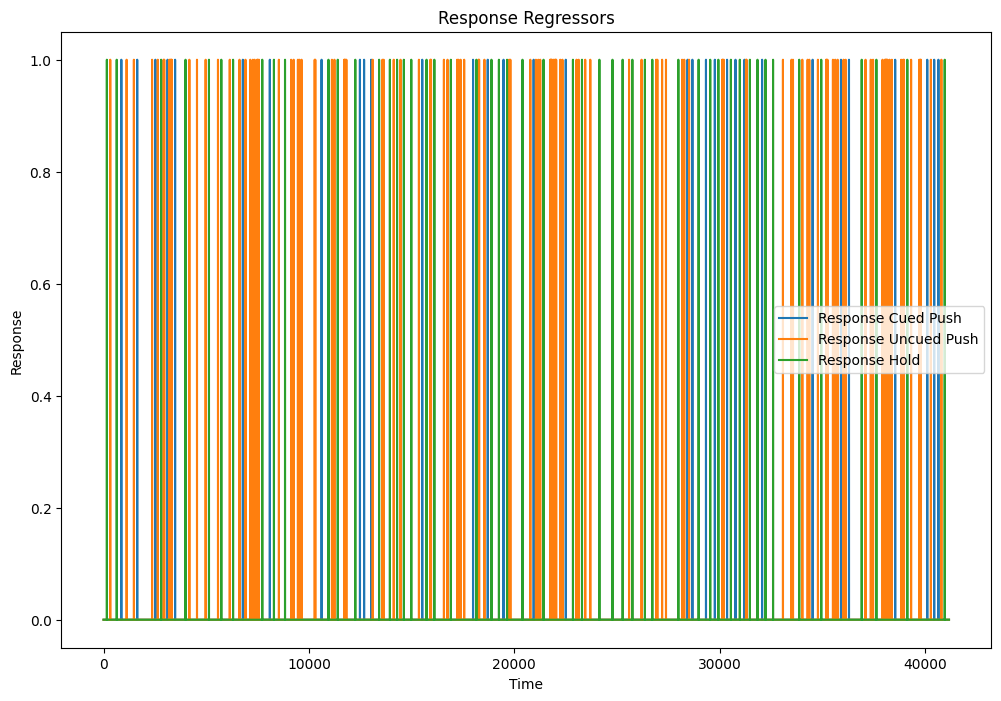

In [9]:
# Plot response regressors
plt.figure(figsize=(12, 8))
plt.plot(regr_resp_cuedpush, label="Response Cued Push")
plt.plot(regr_resp_uncuedpush, label="Response Uncued Push")
plt.plot(regr_resp_hold, label="Response Hold")
plt.legend()
plt.xlabel("Time")
plt.ylabel("Response")
plt.title("Response Regressors")
plt.show()

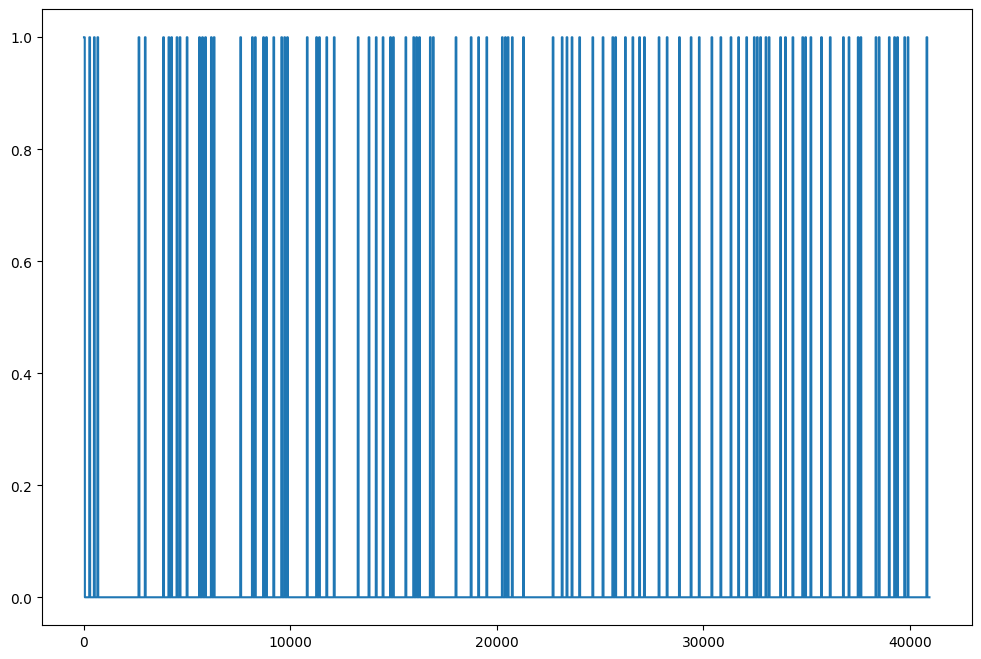

In [ ]:
# Plot reward regressors
plt.figure(figsize=(12, 8))
plt.plot(regr_reward, label="Reward")


In [11]:
regressors, labels = regressor.generate_gonogo_regressors(
    df,
    timestamps,
    go_stim_id=GO_STIM,
    nogo_stim_id=NOGO_STIM,
    uncued_push_id="precued",
    correct_outcome_id="correct",
    lever_push_duration=0.07,
    stimulus_duration=0.15,
    reward_duration=1.5,
)

In [12]:
regressors

array([[0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0],
       ...,
       [0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0]], shape=(41168, 6))

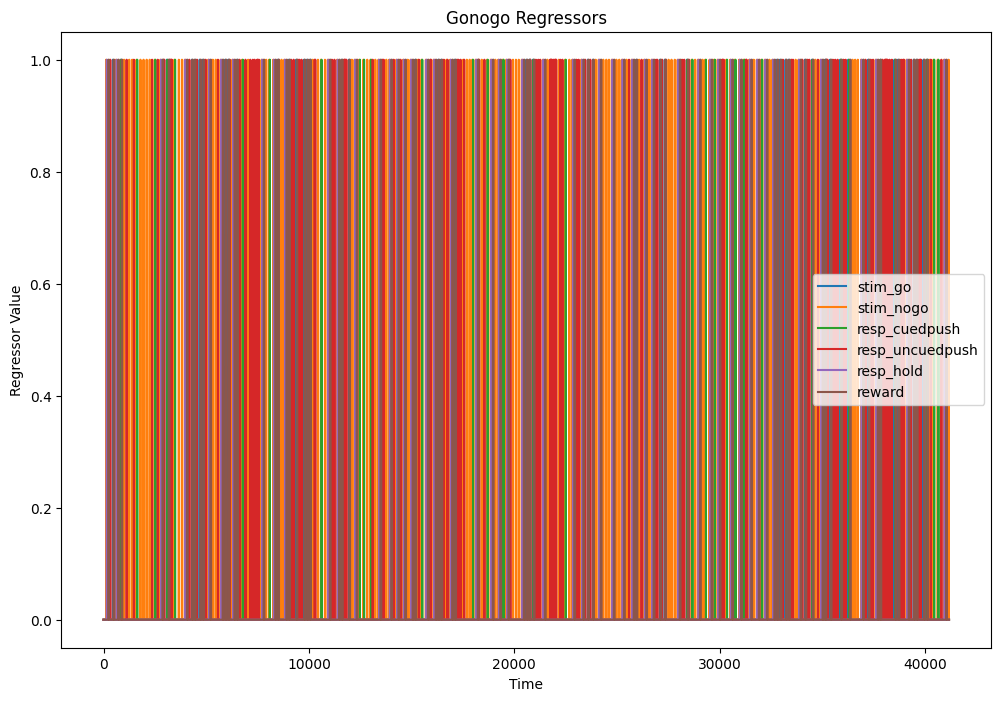

In [15]:
# plot regressors
plt.figure(figsize=(12, 8))
for i, label in enumerate(labels):
    plt.plot(regressors[:, i], label=labels[i])
plt.legend()
plt.xlabel("Time")
plt.ylabel("Regressor Value")
plt.title("Gonogo Regressors")
plt.show()